<>:36: SyntaxWarning: "\-" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\-"? A raw string is also an option.
<>:36: SyntaxWarning: "\-" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\-"? A raw string is also an option.
/tmp/ipykernel_5845/3998401225.py:36: SyntaxWarning: "\-" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\-"? A raw string is also an option.
  axes[i].set_xlabel(f"Posterior on r for parallax measurement of {w_measured[i]} +\- {w_err[i]}")


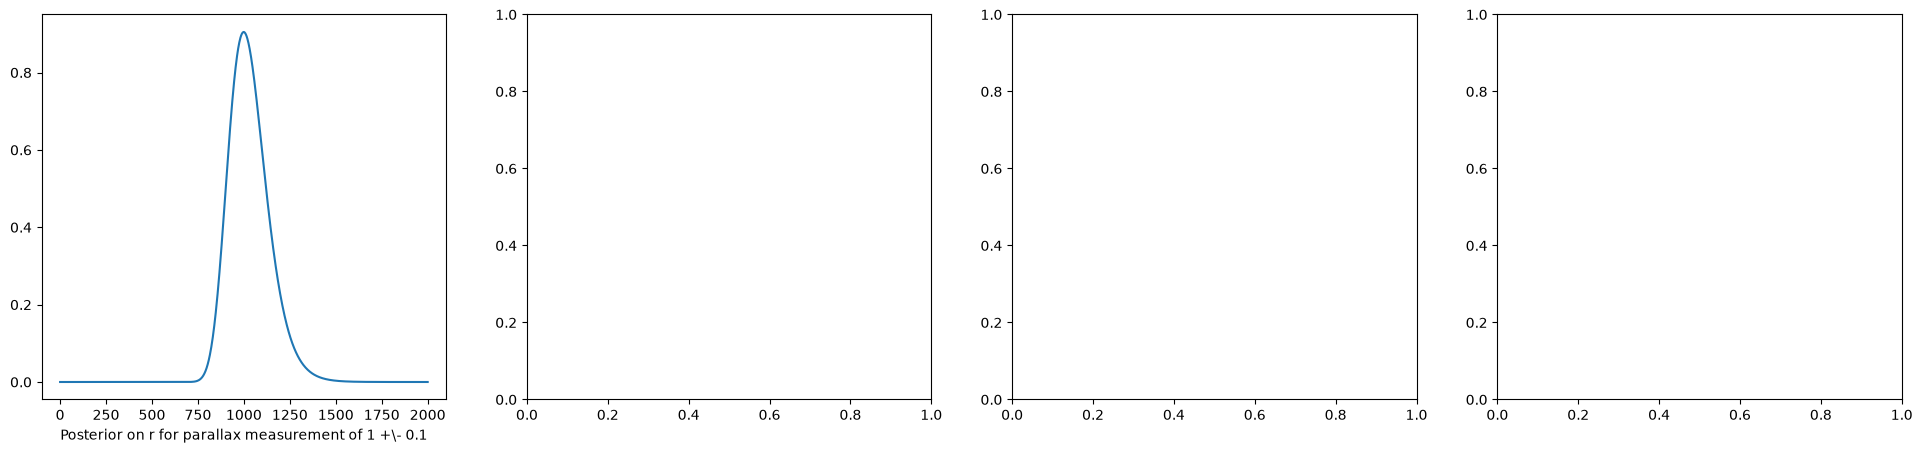

In [ ]:
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import dustmaps.edenhofer2023
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import jax.random as jr
from astropy.io import fits
from hmc_dust.better_hmc import HMCSampler
import jax.scipy.special as jss
import arviz as az


def distance_logprior(r):
    return jnp.where(r > 0, -r/10000, -jnp.inf)

def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2) 
    p_r = distance_logprior(r)
    return p_r + p_w_given_r


fig, axes = plt.subplots(1, 4, figsize = (24, 5))
w_measured = [1]
w_err = [0.1]
r_linspace = jnp.linspace(0.1, 2000, 1000)
for i in range (0, 1):
    axes[i].plot(r_linspace, jnp.exp(logposterior_on_r(r_linspace, w_measured[i], w_err[i])))
    axes[i].set_xlabel(f"Posterior on r for parallax measurement of {w_measured[i]} +\- {w_err[i]}")